# elliprof example: UGC 12517

Fit elliptical isophotes to a real HST image of the galaxy UGC 12517 with **elliprof**.

The steps: look at the image, choose the initial centre by eye, load the mask, subtract the sky, fit, and inspect the profile and the fitted ellipses. The data are in `examples/u12517/`, and all paths are relative to this notebook's folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.patches import Ellipse

import elliprof
from elliprof import load_mask, run_elliprof
from elliprof.regions import profile_ellipses

print("elliprof", elliprof.__version__)
DATA = Path("..") / "examples" / "u12517"
IMAGE = DATA / "u12517j.fits"
MASK = DATA / "u12517j.dmask"

elliprof 0.1.0


## 1. The image

(1022, 1025) (rows, cols)


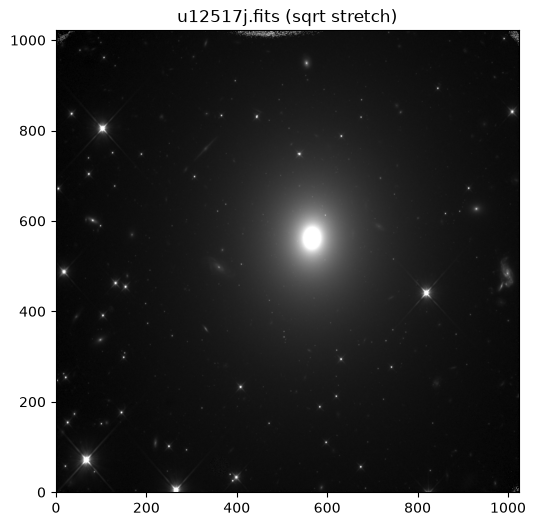

In [2]:
image = fits.getdata(IMAGE)
print(image.shape, "(rows, cols)")

def show(data, ax, title, lo=0.5, hi=99.8):
    vmin, vmax = np.percentile(data, [lo, hi])
    ax.imshow(np.sqrt(np.clip(data - vmin, 0, None)), origin="lower",
              cmap="gray", vmax=np.sqrt(vmax - vmin))
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(6, 6))
show(image, ax, "u12517j.fits (sqrt stretch)")

## 2. Choose the initial centre

Pick the nucleus by eye, here (567, 562). elliprof needs this starting point and does not guess it; ELLIPROF then fits the centre of every isophote.

`X0`, `Y0` are ELLIPROF image coordinates: the centre of the pixel in FITS column *i* is at *i* − 0.5, which is *i* − 1.5 in 0-based numpy/matplotlib indices.

(502.0, 622.0)

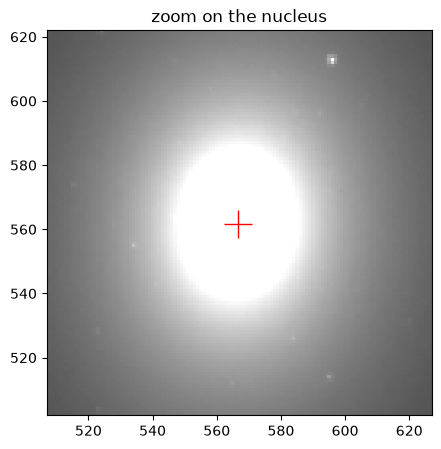

In [3]:
X0, Y0 = 567, 562
fig, ax = plt.subplots(figsize=(5, 5))
show(image, ax, "zoom on the nucleus")
ax.plot(X0 - 0.5, Y0 - 0.5, "r+", ms=20)        # matplotlib pixel centres are at integers
ax.set_xlim(X0 - 60, X0 + 60)
ax.set_ylim(Y0 - 60, Y0 + 60)

## 3. The mask (optional)

0 = ignored, 1 = good. The image is multiplied by the mask after the sky is subtracted, so masked pixels become exactly 0, and ELLIPROF skips pixels that are exactly 0.

masked pixels: 103402 (9.87%)


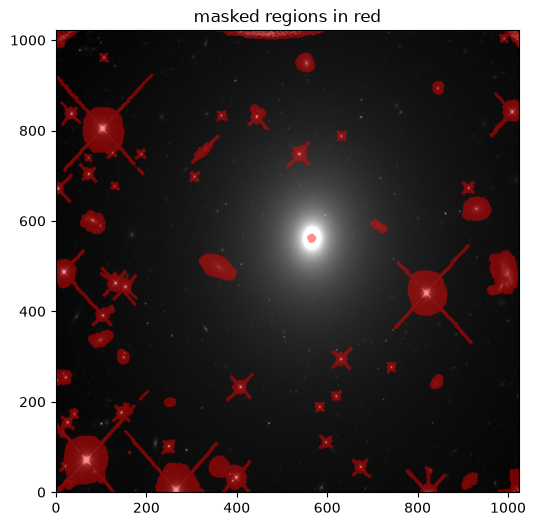

In [4]:
mask = load_mask(str(MASK))
print("masked pixels:", int((mask == 0).sum()), f"({(mask == 0).mean():.2%})")
overlay = np.zeros(mask.shape + (4,))
overlay[mask == 0] = (1, 0, 0, 0.45)
fig, ax = plt.subplots(figsize=(6, 6))
show(image, ax, "masked regions in red")
ax.imshow(overlay, origin="lower")

## 4. Sky (optional)

Either a constant, `sky=`, or a 2-D image of the same size, `sky_image=`. Here a constant is used. A sky image would be passed as `sky_image="background.fits"`, and is subtracted pixel by pixel.

In [5]:
SKY = 3246.0

## 5. Run ELLIPROF

In [6]:
result = run_elliprof(
    IMAGE, x0=X0, y0=Y0, mask=MASK, sky=SKY,
    r0=9, r1=347, nr=23, niter=10, rmstar=True, model=True,
    output_dir="elliprof_output", prefix="u12517j",
)
print("exit code:", result.returncode)
result.profile

exit code: 0


,Rmaj,x0,y0,I0,alpha,ellip,I3,A3,I4,A4,slope
0,9.000000,567.000000,562.000000,486292.812500,3.599998,0.219101,0.000000,0.000000,0.000000,0.000000,-0.232092
1,11.700934,567.651855,562.700378,452421.718750,1.618591,0.262981,0.022035,105.038986,0.011072,54.078465,-0.640556
2,14.968512,567.088135,562.516235,338468.375000,176.615204,0.210783,0.000821,21.314674,0.005510,43.745510,-1.228434
3,18.876940,567.083740,562.529297,253091.046875,176.401520,0.213066,0.000897,33.040955,0.003070,42.612385,-1.301329
4,23.504982,567.077759,562.509338,189528.625000,176.775818,0.214315,0.001354,99.142105,0.002324,41.390701,-1.392199
5,28.935982,567.070557,562.497498,140170.546875,176.619904,0.213945,0.000996,82.614731,0.003393,48.532631,-1.505439
6,35.257843,567.076843,562.456238,103819.859375,176.872528,0.214785,0.001467,48.100307,0.003850,48.799110,-1.552681
7,42.563046,567.021362,562.466675,77867.500000,176.658112,0.218771,0.002330,34.000114,0.003373,50.650860,-1.571103
8,50.948627,566.993591,562.393921,58720.250000,176.576508,0.219374,0.000866,13.221622,0.002873,46.133461,-1.628239
9,60.516190,566.956665,562.228149,44176.480469,176.561523,0.216967,0.002807,5.582406,0.004897,43.027569,-1.702832


Columns: semi-major axis `Rmaj` (pixels), isophote centre `x0`, `y0`, mean intensity `I0`, position angle `alpha` (the major axis is at `alpha + 90`° from +x), ellipticity `ellip` = 1 − b/a, the 3θ and 4θ harmonic amplitudes and phases `I3`, `A3`, `I4`, `A4`, and the slope d log I / d log r.

The innermost isophote (r = 9) lies inside the masked nucleus, so ELLIPROF could not fit it and it keeps its starting values.

## 6. Profiles

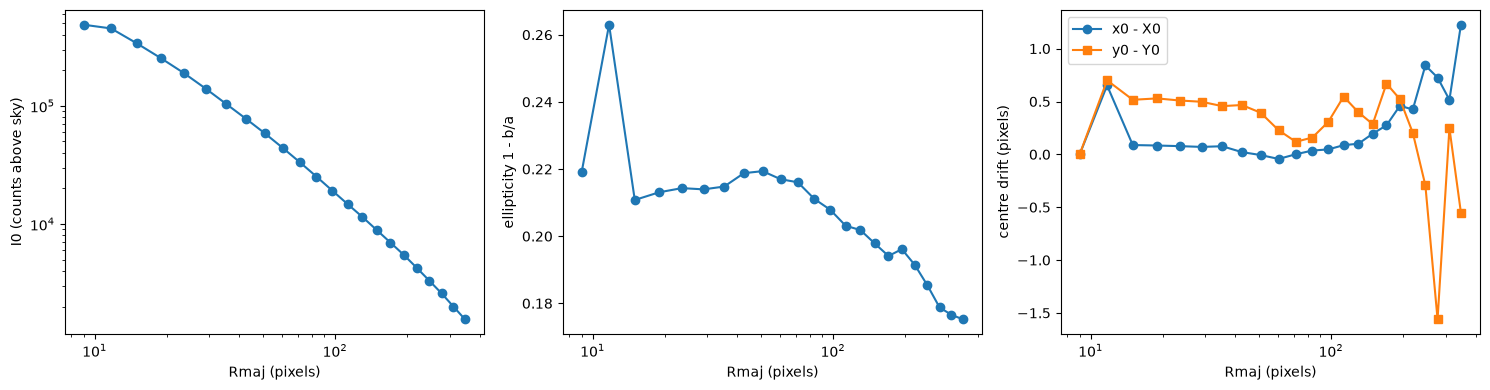

In [7]:
p = result.profile
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].loglog(p.Rmaj, p.I0, "o-")
axes[0].set_ylabel("I0 (counts above sky)")
axes[1].semilogx(p.Rmaj, p.ellip, "o-")
axes[1].set_ylabel("ellipticity 1 - b/a")
axes[2].semilogx(p.Rmaj, p.x0 - X0, "o-", label="x0 - X0")
axes[2].semilogx(p.Rmaj, p.y0 - Y0, "s-", label="y0 - Y0")
axes[2].set_ylabel("centre drift (pixels)")
axes[2].legend()
for ax in axes:
    ax.set_xlabel("Rmaj (pixels)")
fig.tight_layout()

## 7. Fitted ellipses on the image

`profile_ellipses` gives DS9 ellipses (DS9 puts pixel centres at whole numbers, counting from 1). matplotlib counts from 0, so we subtract 1.

(162.0, 962.0)

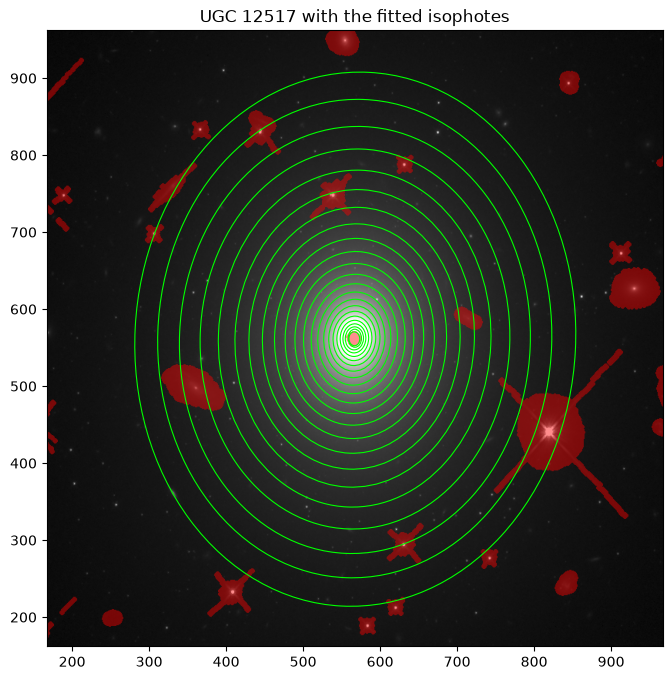

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
show(image - SKY, ax, "UGC 12517 with the fitted isophotes")
ax.imshow(overlay, origin="lower")
for x, y, a, b, angle in profile_ellipses(p):
    ax.add_patch(Ellipse((x - 1, y - 1), 2 * a, 2 * b, angle=angle,
                         fill=False, color="lime", lw=0.8))
ax.set_xlim(X0 - 400, X0 + 400)
ax.set_ylim(Y0 - 400, Y0 + 400)

## 8. Output files

In [9]:
for name in ("prf_path", "csv_path", "reg_path", "model_path"):
    print(f"{name:11s}", getattr(result, name))

prf_path    elliprof_output/u12517j.prf
csv_path    elliprof_output/u12517j.csv
reg_path    elliprof_output/u12517j.reg
model_path  elliprof_output/u12517j_model.fits


To view the ellipses in DS9, run `ds9 ../examples/u12517/u12517j.fits -regions elliprof_output/u12517j.reg`, or use *Region → Open…*.